In [1]:
# ============================================================
# Setup
# ============================================================
import numpy as np, torch, random
import matplotlib.pyplot as plt
from collections import Counter

from model import WizNet
from cards import Card, CardDeck, COLORS
from observations import BidObservation
from player import encode, encode_bids

CKPT = "relevant_checkpoints/up_20260819_000156_12500.pt"

net = WizNet(317, 20, 256)
net.load_state_dict(torch.load(CKPT, map_location="cpu"))
net.eval()

WizNet(
  (layer1): Linear(in_features=317, out_features=256, bias=True)
  (layer2): Linear(in_features=256, out_features=256, bias=True)
  (bid_head): Linear(in_features=256, out_features=21, bias=True)
  (card_head): Linear(in_features=256, out_features=60, bias=True)
  (value_head): Linear(in_features=256, out_features=1, bias=True)
)

In [2]:
# ============================================================
# Adapter — Feldnamen gegen observations.py pruefen!
# ============================================================
def make_bid_obs(hand, trump, round_nr, bids_and_wins=None, n_before=0):
    if bids_and_wins is None:
        bids_and_wins = [(None, 0)] * 3
    return BidObservation(
        hand=hand,
        trump=trump,
        bids_and_wins=bids_and_wins,
        n_players_bid_before_me=n_before,
        round_nr=round_nr,
    )

def enc_bid(hand, trump="red", round_nr=20, bids_and_wins=None, n_before=0):
    obs = make_bid_obs(hand, trump, round_nr, bids_and_wins, n_before)
    return np.asarray(encode(obs), dtype=np.float32)

FULL_DECK = [Card(color=c, value=v) for c in COLORS for v in range(15)]

def card_index(card):
    return COLORS.index(card.color) * 15 + card.value

def random_hand(n, rng):
    return rng.sample(FULL_DECK, n)

_e = enc_bid(random_hand(20, random.Random(0)), trump="red", round_nr=20)
assert _e.shape == (317,), _e.shape
assert _e[:60].sum() == 20
assert _e[60:120].sum() == 0, "played sollte beim Bieten leer sein"
assert _e[125:305].sum() == 0, "trick sollte beim Bieten leer sein"
assert _e[314] == 20 and _e[316] == 1.0, "meta: round_nr und is_bid"

a = enc_bid(random_hand(20, random.Random(0)), trump="red")
b = enc_bid(random_hand(20, random.Random(0)), trump="blue")
diff = np.flatnonzero(a != b)
assert set(diff) <= set(range(120, 125)), f"Trumpf-Slots unerwartet: {diff}"
print("Adapter ok")

Adapter ok


In [3]:
@torch.no_grad()
def bid_logits(hand, trump="red", round_nr=20, **kw):
    lg, _, v = net(torch.from_numpy(enc_bid(hand, trump, round_nr, **kw)))
    return lg[:round_nr+1], v.item()

def expected_bid(hand, trump="red", round_nr=20, **kw):
    lg, _ = bid_logits(hand, trump, round_nr, **kw)
    p = torch.softmax(lg, 0)
    return float((p * torch.arange(len(p), dtype=torch.float32)).sum())

In [25]:
# ============================================================
# 1a. Gebotsverteilung
# ============================================================
def bid_distribution(n_hands=2000, round_nr=20, trump="red", seed=0):
    rng = random.Random(seed)
    return np.array([int(bid_logits(random_hand(round_nr, rng), trump, round_nr)[0].argmax())
                     for _ in range(n_hands)])

R = 20
bids20 = bid_distribution(2000, round_nr=R)
exp_tricks = R / 3
print(f"E[Stiche] = {exp_tricks:.2f}   mean bid = {bids20.mean():.2f}   "
      f"max = {bids20.max()}   Bias = {bids20.mean()-exp_tricks:+.2f}\n")
for k, c in sorted(Counter(bids20).items()):
    print(f"  Gebot {k:2d}: {c:5d}  ({100*c/len(bids20):5.1f}%)  {'#'*int(60*c/len(bids20))}")

E[Stiche] = 6.67   mean bid = 5.78   max = 6   Bias = -0.89

  Gebot  2:     1  (  0.1%)  
  Gebot  3:    12  (  0.6%)  
  Gebot  4:    86  (  4.3%)  ##
  Gebot  5:   230  ( 11.5%)  ######
  Gebot  6:  1671  ( 83.5%)  ##################################################


 Klasse   mean     std      max    Status
    0    -12.11    1.46    -8.69   EINGEFROREN
    1    -38.81    9.63     5.28   aktiv
    2    -26.07    8.27    11.24   aktiv
    3    -12.17    6.07    12.76   aktiv
    4      1.15    2.07     7.09   aktiv
    5     10.69    2.77    16.82   aktiv
    6     17.14    8.80    35.84   aktiv
    7     -4.72    1.19    -3.22   EINGEFROREN
    8    -11.36    0.96    -9.22   EINGEFROREN
    9    -12.19    1.04   -10.07   EINGEFROREN
   10    -10.52    0.98    -8.75   EINGEFROREN
   11    -12.02    1.08    -9.94   EINGEFROREN
   12    -13.57    1.67    -8.55   EINGEFROREN
   13    -12.48    1.42    -5.93   EINGEFROREN
   14    -11.96    1.25    -8.18   EINGEFROREN
   15    -11.34    1.40    -5.25   EINGEFROREN
   16     -8.51    1.05    -3.79   EINGEFROREN
   17    -10.08    1.35    -5.69   EINGEFROREN
   18     -9.69    1.34    -3.00   EINGEFROREN
   19     -8.03    1.28    -1.02   EINGEFROREN
   20    -10.80    2.58     0.03   aktiv


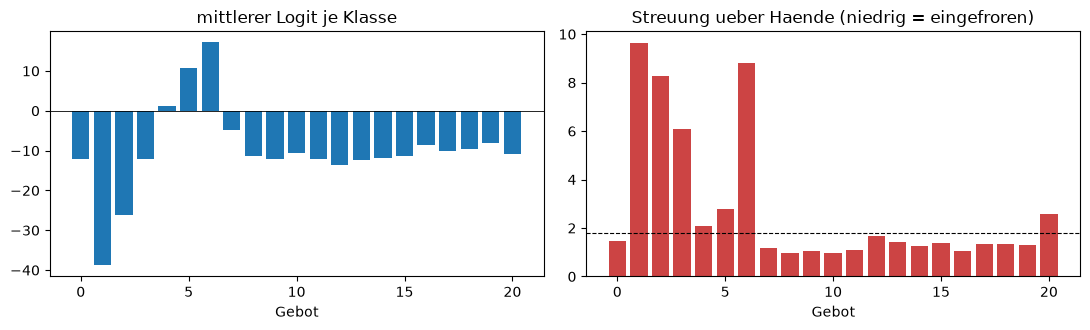

In [26]:
# ============================================================
# 1b. Eingefrorene Klassen
# ============================================================
@torch.no_grad()
def logit_matrix(n_hands=1000, round_nr=20, trump="red", seed=7):
    rng = random.Random(seed)
    return torch.stack([bid_logits(random_hand(round_nr, rng), trump, round_nr)[0]
                        for _ in range(n_hands)])

M = logit_matrix(1000, round_nr=20)
mu, sd, mx = M.mean(0), M.std(0), M.max(0).values

print(" Klasse   mean     std      max    Status")
for k in range(M.shape[1]):
    print(f"   {k:2d}   {mu[k]:7.2f} {sd[k]:7.2f} {mx[k]:8.2f}   "
          f"{'aktiv' if sd[k] > 1.8 else 'EINGEFROREN'}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].bar(range(len(mu)), mu.numpy()); ax[0].axhline(0, lw=.6, c="k")
ax[0].set_title("mittlerer Logit je Klasse"); ax[0].set_xlabel("Gebot")
ax[1].bar(range(len(sd)), sd.numpy(), color="#c44"); ax[1].axhline(1.8, ls="--", lw=.8, c="k")
ax[1].set_title("Streuung ueber Haende (niedrig = eingefroren)"); ax[1].set_xlabel("Gebot")
plt.tight_layout(); plt.show()

 Klasse   mean     std      max    Status
    0     -6.08    0.88    -4.38   EINGEFROREN
    1      3.21   11.58    39.08   aktiv
    2      7.70    7.99    27.96   aktiv
    3      9.04    3.67    14.71   aktiv
    4      4.47    1.99     7.60   aktiv
    5     -4.60    5.73     7.09   aktiv
    6    -18.87    9.87     6.73   aktiv
    7     -8.47    2.09    -3.77   aktiv
    8     -8.42    0.71    -6.48   EINGEFROREN


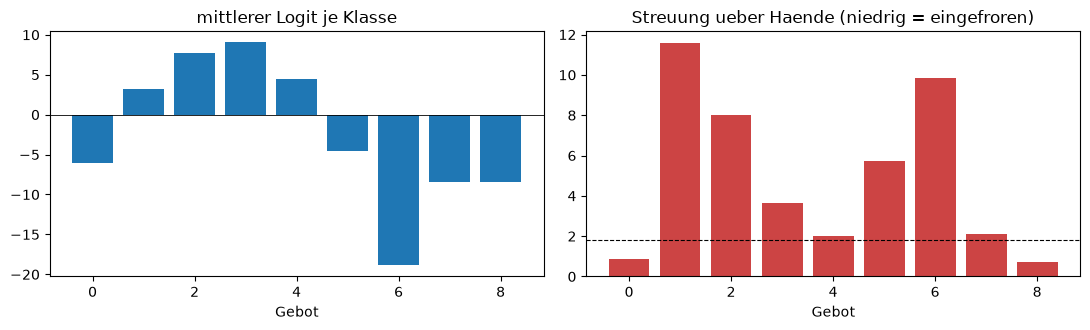

In [22]:
# ============================================================
# 1b. Eingefrorene Klassen
# ============================================================
@torch.no_grad()
def logit_matrix(n_hands=1000, round_nr=8, trump="red", seed=7):
    rng = random.Random(seed)
    return torch.stack([bid_logits(random_hand(round_nr, rng), trump, round_nr)[0]
                        for _ in range(n_hands)])

M = logit_matrix(1000, round_nr=8)
mu, sd, mx = M.mean(0), M.std(0), M.max(0).values

print(" Klasse   mean     std      max    Status")
for k in range(M.shape[1]):
    print(f"   {k:2d}   {mu[k]:7.2f} {sd[k]:7.2f} {mx[k]:8.2f}   "
          f"{'aktiv' if sd[k] > 1.8 else 'EINGEFROREN'}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].bar(range(len(mu)), mu.numpy()); ax[0].axhline(0, lw=.6, c="k")
ax[0].set_title("mittlerer Logit je Klasse"); ax[0].set_xlabel("Gebot")
ax[1].bar(range(len(sd)), sd.numpy(), color="#c44"); ax[1].axhline(1.8, ls="--", lw=.8, c="k")
ax[1].set_title("Streuung ueber Haende (niedrig = eingefroren)"); ax[1].set_xlabel("Gebot")
plt.tight_layout(); plt.show()

In [27]:
# ============================================================
# 1c. Rang-Test
# ============================================================
def rank_ratio(M):
    if M.shape[0] < 30: return float("nan")
    s = torch.linalg.svdvals(M - M.mean(0, keepdim=True))
    return float(s[0] / s.sum())

for r in (5, 10, 14, 20):
    Mr = logit_matrix(600, round_nr=r, seed=3)
    print(f"  Runde {r:2d}:  s0/sum = {rank_ratio(Mr):.3f}   absmax = {Mr.abs().max():6.2f}")

  Runde  5:  s0/sum = 0.880   absmax =  36.73
  Runde 10:  s0/sum = 0.826   absmax =  44.29
  Runde 14:  s0/sum = 0.826   absmax =  46.70
  Runde 20:  s0/sum = 0.801   absmax =  61.55


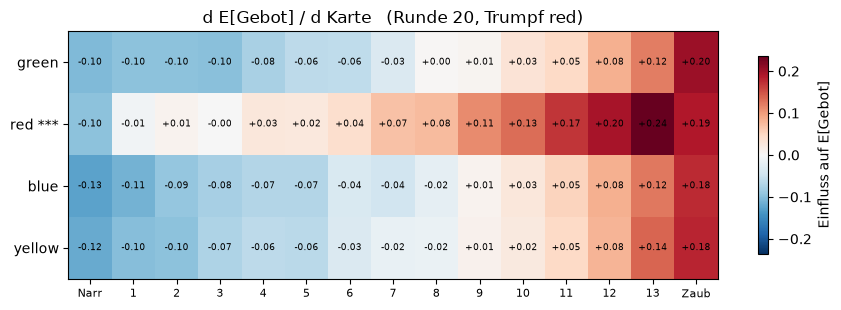

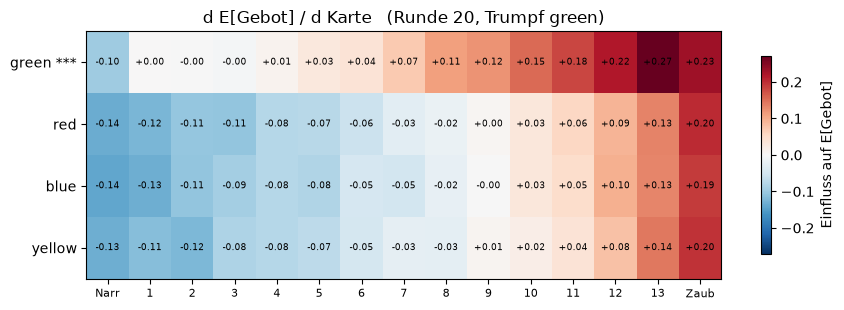

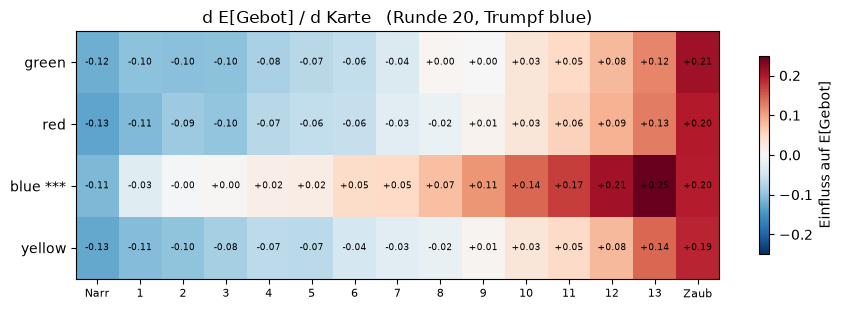

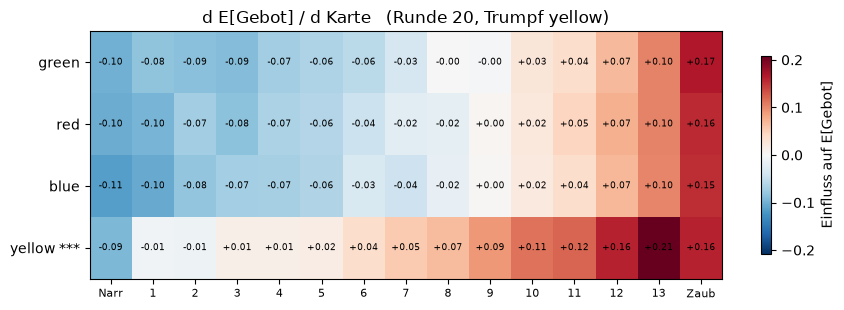

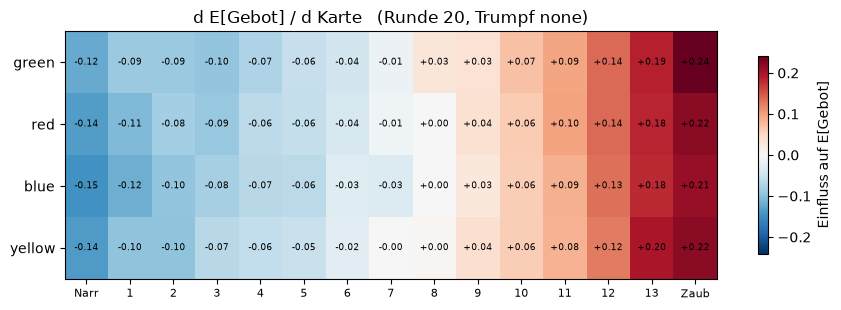

In [4]:
# ============================================================
# 2. Gradienten-Attribution
# ============================================================
def card_attribution(n_hands=400, round_nr=20, trump="red", seed=5):
    rng = random.Random(seed)
    acc = torch.zeros(60)
    for _ in range(n_hands):
        x = torch.from_numpy(enc_bid(random_hand(round_nr, rng), trump, round_nr))
        x.requires_grad_(True)
        lg, _, _ = net(x)
        p = torch.softmax(lg[:round_nr+1], 0)
        (p * torch.arange(round_nr + 1, dtype=torch.float32)).sum().backward()
        acc += x.grad[:60]
    return (acc / n_hands).reshape(4, 15)      # [Farbe, Wert]

def plot_attr(A, trump="red", lim=None, title=None):
    A = A.numpy() if torch.is_tensor(A) else A
    if lim is not None:
        lim = lim
    else:
        lim = np.abs(A).max()
    fig, ax = plt.subplots(figsize=(9, 3.2))
    im = ax.imshow(A, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
    ax.set_xticks(range(15))
    ax.set_xticklabels(["Narr"] + [str(v) for v in range(1, 14)] + ["Zaub"], fontsize=8)
    ax.set_yticks(range(4))
    ax.set_yticklabels([c + (" ***" if c == trump else "") for c in COLORS])
    for i in range(4):
        for j in range(15):
            ax.text(j, i, f"{A[i,j]:+.2f}", ha="center", va="center", fontsize=6.5)
    ax.set_title(title or f"d E[Gebot] / d Karte   (Runde 20, Trumpf {trump})")
    fig.colorbar(im, ax=ax, shrink=.8, label="Einfluss auf E[Gebot]")
    plt.tight_layout(); plt.show()

trumps=["red", "green", "blue", "yellow", "none"]

for trump in trumps:
    ATTR = card_attribution(400, round_nr=20, trump=trump)
    plot_attr(ATTR, trump)

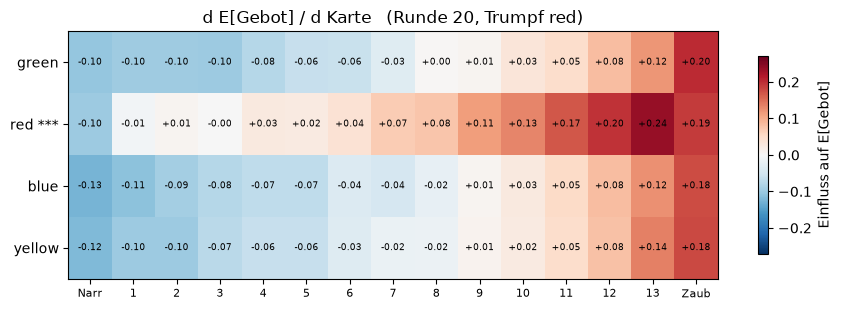

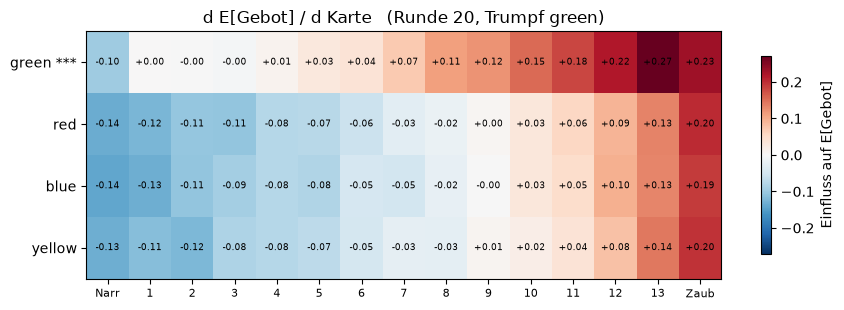

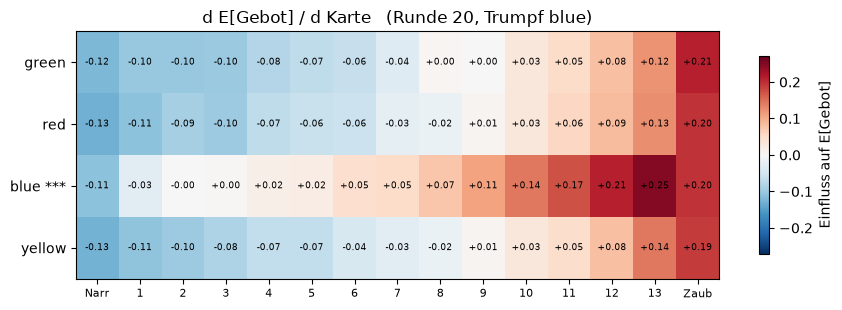

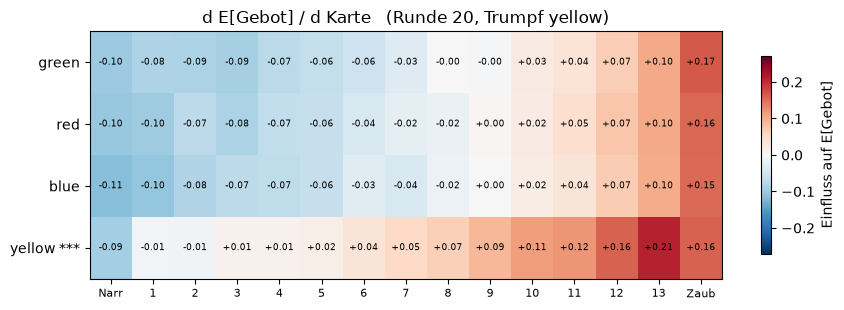

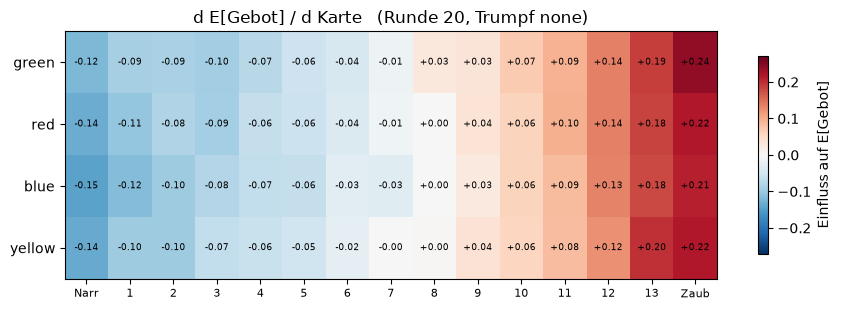

In [5]:
# global reference point for E values
trumps=["red", "green", "blue", "yellow", "none"]

ATTRS = {t: card_attribution(400, 20, t) for t in trumps}
lim = max(np.abs(A.numpy()).max() for A in ATTRS.values())

for trump in trumps:
    at = ATTRS[trump]
    plot_attr(at, trump, lim)

In [6]:
# ============================================================
# 2b. Trumpf-Test — Diagonale muss herausstechen
# ============================================================
rows = {t: card_attribution(250, round_nr=20, trump=t, seed=5).mean(1) for t in COLORS}

print("Zeilen = Trumpffarbe, Spalten = Farbe auf der Hand")
print("        " + "".join(f"{c:>9s}" for c in COLORS))
for t in COLORS:
    print(f"  {t:6s}" + "".join(f"{rows[t][i]:+9.3f}" + ("*" if COLORS[i] == t else " ")
                                for i in range(4)))

Zeilen = Trumpffarbe, Spalten = Farbe auf der Hand
            green      red     blue   yellow
  green    +0.090*   -0.015    -0.017    -0.015 
  red      -0.009    +0.077*   -0.013    -0.006 
  blue     -0.011    -0.014    +0.079*   -0.008 
  yellow   -0.014    -0.014    -0.015    +0.067*


In [7]:
# ============================================================
# 3. Ablation — diskrete Gegenprobe
# ============================================================
def card_ablation(cards, n=150, round_nr=20, trump="red", seed=1):
    rng = random.Random(seed)
    out = {}
    for card in cards:
        pool = [c for c in FULL_DECK if card_index(c) != card_index(card)]
        d = []
        for _ in range(n):
            hand = rng.sample(pool, round_nr)
            d.append(expected_bid([card] + hand[1:], trump, round_nr)
                     - expected_bid(hand, trump, round_nr))
        out[f"{card.color}{card.value}"] = float(np.mean(d))
    return out

probe = [Card(color="red", value=v) for v in (0, 5, 10, 13, 14)] + \
        [Card(color="blue", value=v) for v in (13, 14)]
abl = card_ablation(probe, n=150)

print(f"{'Karte':>10}  {'Ablation':>9}  {'Gradient':>9}")
for c in probe:
    print(f"{c.color+str(c.value):>10}  {abl[f'{c.color}{c.value}']:+9.3f}  "
          f"{ATTR[COLORS.index(c.color), c.value].item():+9.3f}")

     Karte   Ablation   Gradient
      red0     -0.128     -0.135
      red5     +0.016     -0.058
     red10     +0.129     +0.061
     red13     +0.258     +0.184
     red14     +0.167     +0.217
    blue13     +0.120     +0.179
    blue14     +0.196     +0.211


  r  E[Stiche]  mean bid  max bid    Bias
  3       1.00      1.16        3   +0.16
  5       1.67      1.69        4   +0.02
  8       2.67      2.65        6   -0.01
 10       3.33      3.42        6   +0.09
 12       4.00      4.30        6   +0.30
 14       4.67      4.68        6   +0.01
 16       5.33      5.11        6   -0.22
 18       6.00      5.57        6   -0.43
 20       6.67      5.80        6   -0.86


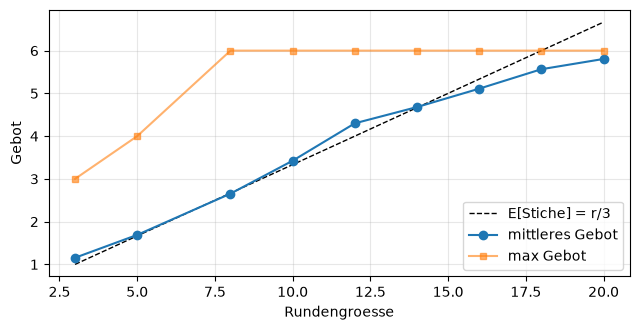

In [8]:
# ============================================================
# 4. Rundengroessen-Sweep
# ============================================================
def sweep(sizes=(3,5,8,10,12,14,16,18,20), n_hands=200, trump="red", seed=1):
    rng = random.Random(seed)
    rec = []
    for r in sizes:
        b = [int(bid_logits(random_hand(r, rng), trump, r)[0].argmax()) for _ in range(n_hands)]
        rec.append((r, r/3, float(np.mean(b)), max(b)))
    return rec

rec = sweep()
print(f"{'r':>3} {'E[Stiche]':>10} {'mean bid':>9} {'max bid':>8} {'Bias':>7}")
for r, e, m, mx in rec:
    print(f"{r:3d} {e:10.2f} {m:9.2f} {mx:8d} {m-e:+7.2f}")

rs = [x[0] for x in rec]
plt.figure(figsize=(6.5, 3.4))
plt.plot(rs, [x[1] for x in rec], "--", c="k", lw=1, label="E[Stiche] = r/3")
plt.plot(rs, [x[2] for x in rec], "o-", label="mittleres Gebot")
plt.plot(rs, [x[3] for x in rec], "s-", ms=4, alpha=.6, label="max Gebot")
plt.xlabel("Rundengroesse"); plt.ylabel("Gebot"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [13]:
def hand_strength(hand):
    """Grober Anteil vermutlich gewinnender Karten."""
    s = 0.0
    for c in hand:
        if c.value == 14:   s += 1.0      # Zauberer
        elif c.value == 0:  s += 0.0      # Narr
        elif c.value >= 11: s += 0.5
        elif c.value >= 8:  s += 0.25
    return s / len(hand)                   # normiert auf [0, 1]


def policy_surface(round_sizes=range(2, 21), n_bins=8, n_hands=8000,
                   trump="red", seed=0):
    rng = random.Random(seed)
    S = np.full((len(round_sizes), n_bins), np.nan)
    N = np.zeros((len(round_sizes), n_bins))
    acc = np.zeros((len(round_sizes), n_bins))

    for ri, r in enumerate(round_sizes):
        for _ in range(n_hands // len(round_sizes)):
            hand = random_hand(r, rng)
            b = int(bid_logits(hand, trump, r)[0].argmax())
            bi = min(int(hand_strength(hand) * n_bins), n_bins - 1)
            acc[ri, bi] += b
            N[ri, bi]   += 1

    S = np.where(N > 5, acc / np.maximum(N, 1), np.nan)
    return S, N

def plot_surface(S, round_sizes, n_bins=8, trump="red"):
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(S, origin="lower", aspect="auto", cmap="viridis")
    ax.set_yticks(range(len(round_sizes)))
    ax.set_yticklabels(round_sizes)
    ax.set_xticks(range(n_bins))
    ax.set_xticklabels([f"{(i+.5)/n_bins:.2f}" for i in range(n_bins)], fontsize=8)
    ax.set_xlabel("Handstaerke"); ax.set_ylabel("Rundengroesse")
    for i in range(S.shape[0]):
        for j in range(S.shape[1]):
            if not np.isnan(S[i, j]):
                ax.text(j, i, f"{S[i,j]:.1f}", ha="center", va="center",
                        fontsize=6.5, color="w")
    fig.colorbar(im, ax=ax, label="mittleres Gebot")
    ax.set_title(f"Policy-Oberflaeche (Trumpf {trump})")
    plt.tight_layout(); plt.show()

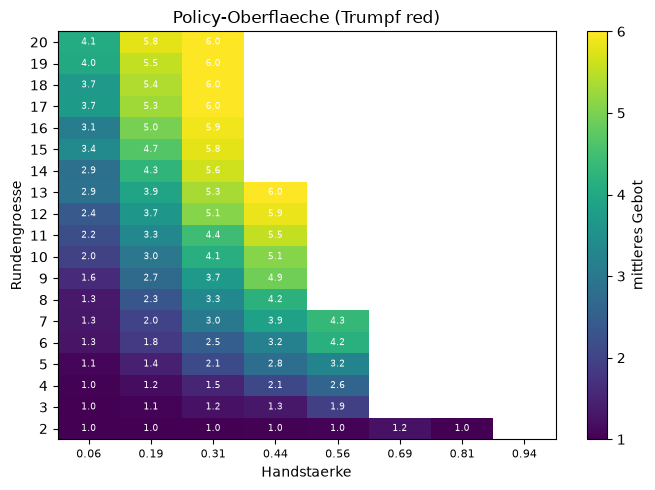

In [10]:
S, N = policy_surface()

plot_surface(S, round_sizes=range(2, 21))

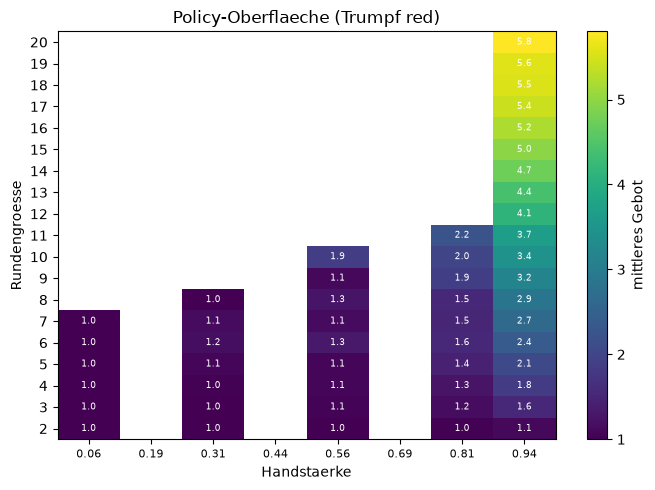

In [12]:
S, N = policy_surface()

plot_surface(S, round_sizes=range(2, 21))